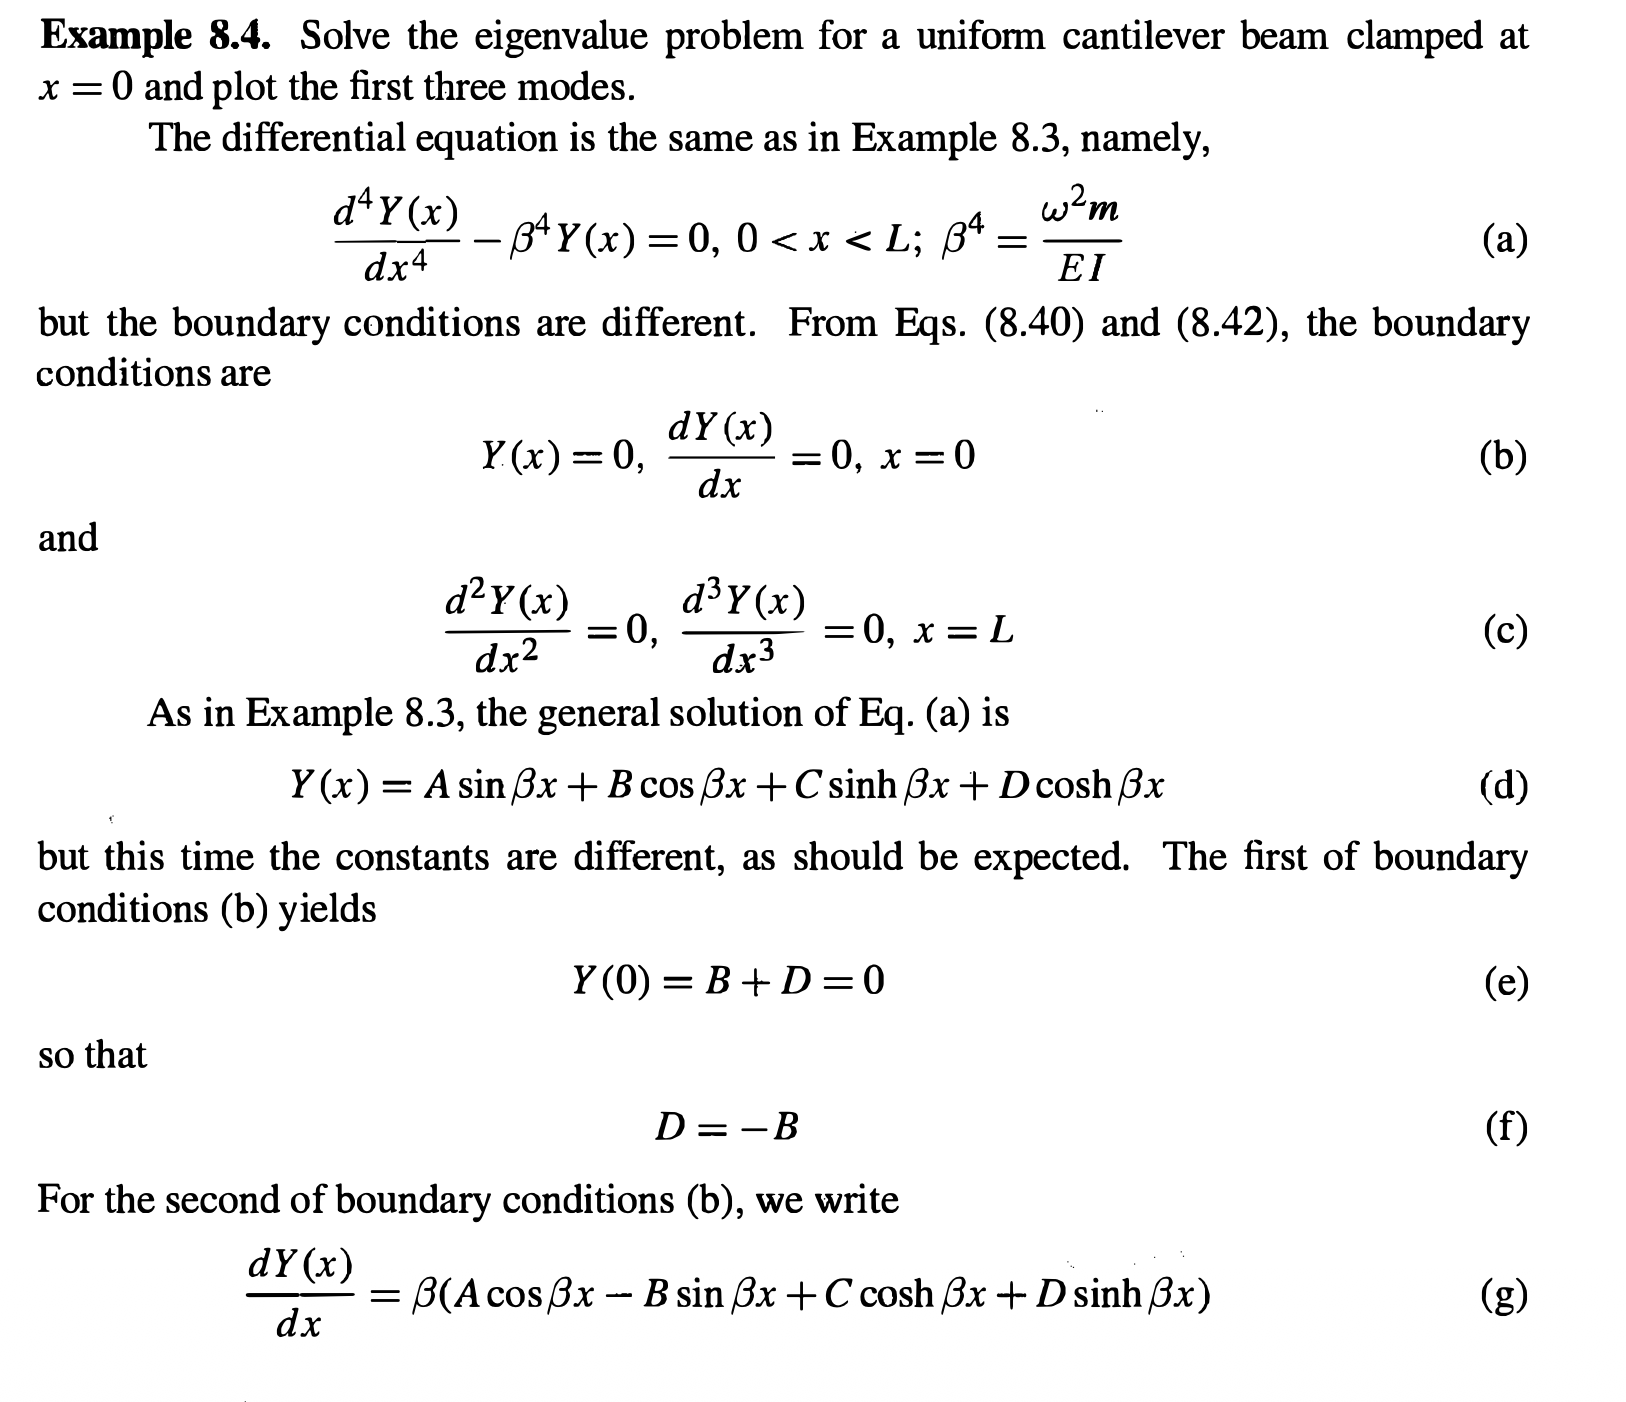

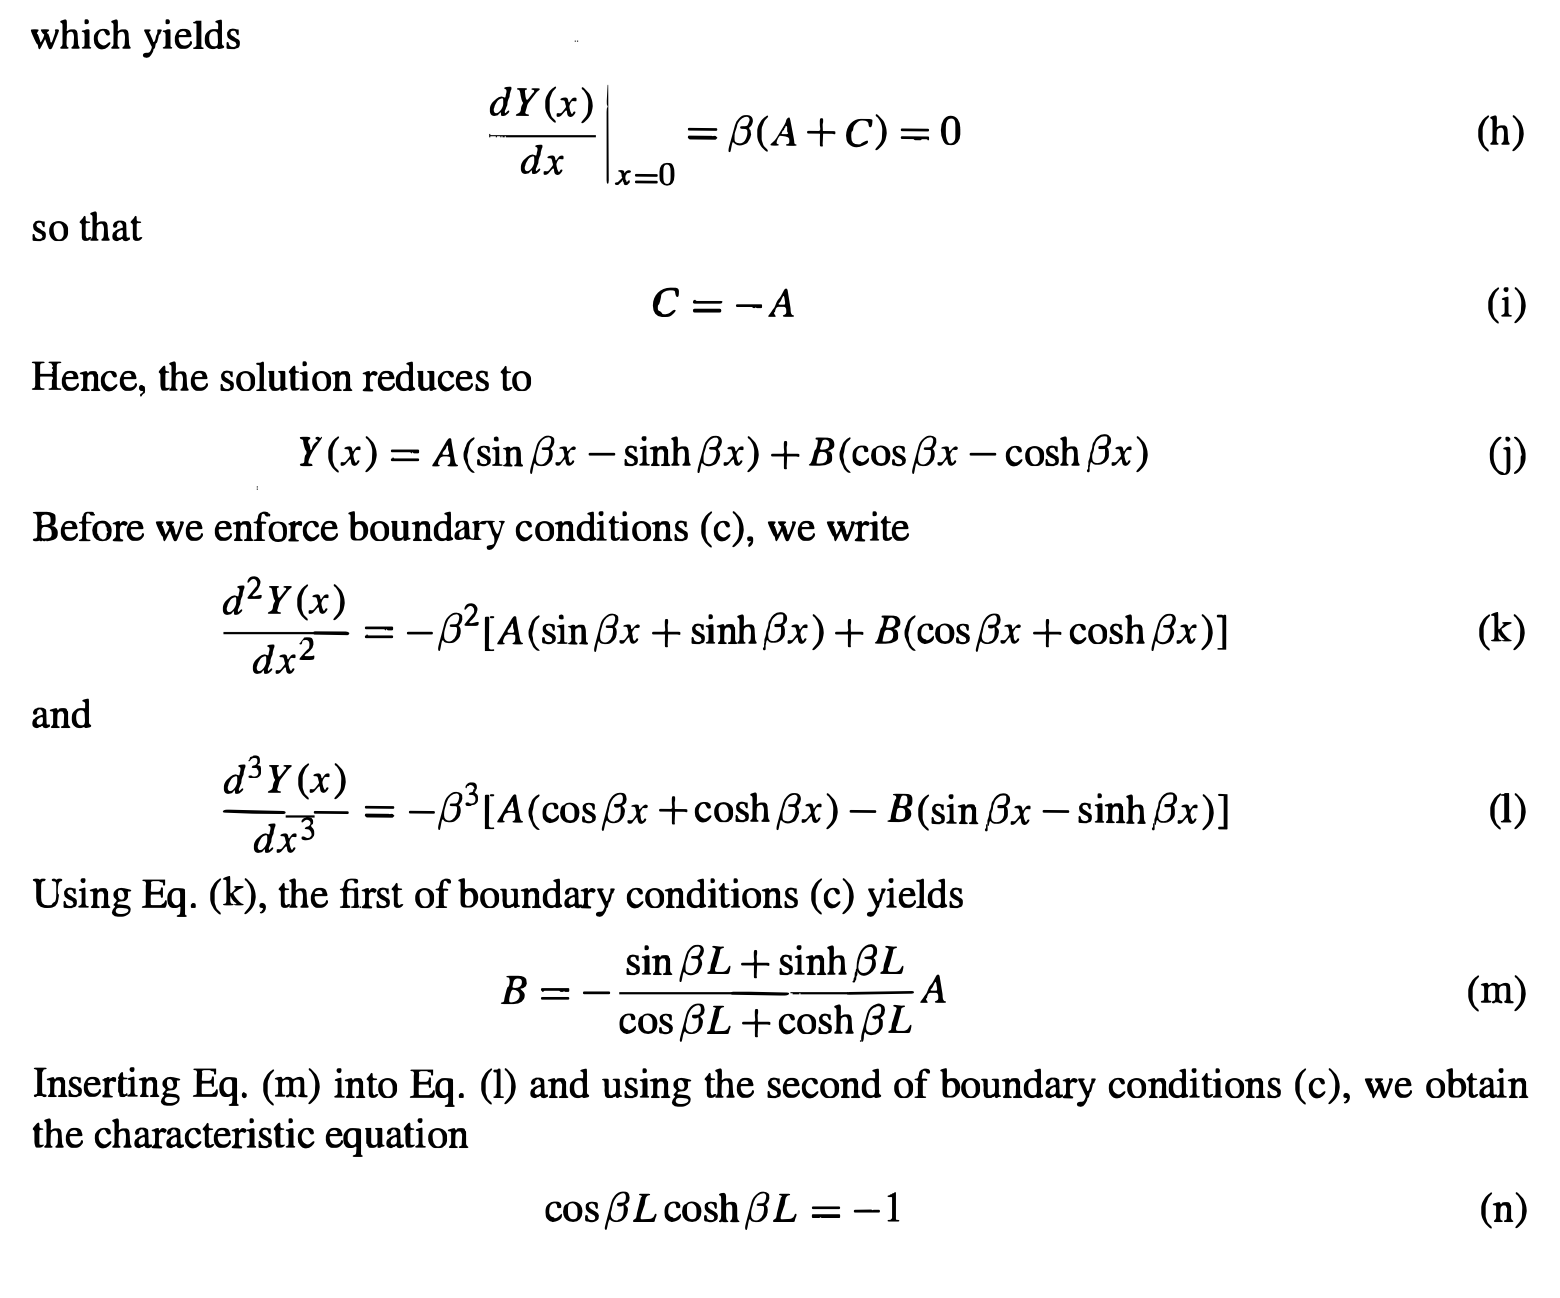

characteristic equation is:

$$cosx \cdot cosh x = -1$$

🔵 符号推导结果 (General Solution)
1. 通用位移方程 Y(x):
A⋅sin(β⋅x) + B⋅cos(β⋅x) + C⋅sinh(β⋅x) + D⋅cosh(β⋅x)
--------------------
2. 代入左端边界条件 (x=0, Clamped):
   Y(0)=0 => D = -B
   Y'(0)=0 => C = -A
   简化后的 Y(x):
A⋅(sin(β⋅x) - sinh(β⋅x)) + B⋅(cos(β⋅x) - cosh(β⋅x))
--------------------
3. 特征方程 (Frequency Equation):
   cos(beta*L) * cosh(beta*L) + 1 = 0

🟠 数值求解结果 (Numerical Results)
Mode 1:
  beta_1 * L = 1.875104
--------------------
Mode 2:
  beta_2 * L = 4.694091
--------------------
Mode 3:
  beta_3 * L = 7.854757
--------------------


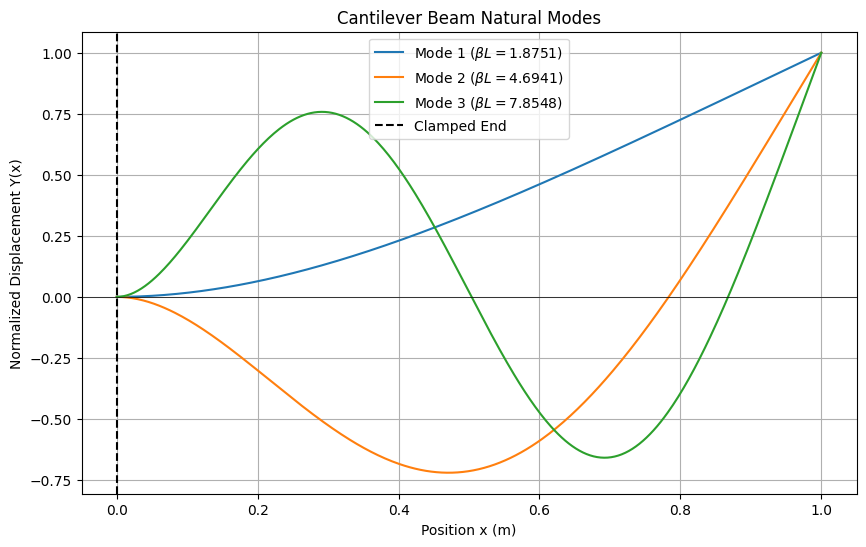

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import sympy as sp

# ==========================================
# 🟢 考试配置区 (在这里修改数值)
# ==========================================
# 模式选择：True = 有具体数值, False = 只需要通解和通用振型图
HAS_NUMERICAL_VALUES = False 

# 如果 HAS_NUMERICAL_VALUES = True，请填写以下参数：
# 如果题目没给，保持默认即可，不影响无量纲(beta*L)的计算
L_val = 1.0        # 梁长 L (m)
E_val = 210e9      # 弹性模量 E (Pa)
I_val = 1.0e-6     # 截面惯性矩 I (m^4)
m_val = 7850       # 单位长度质量 m (kg/m) = rho * A

# ==========================================
# 📘 第一部分：符号推导 (帮你写通解公式)
# ==========================================
def symbolic_derivation():
    print("="*40)
    print("🔵 符号推导结果 (General Solution)")
    print("="*40)
    
    x, L, beta = sp.symbols('x L beta')
    A, B, C, D = sp.symbols('A B C D')
    
    # 1. 通解公式 (Eq. d)
    Y = A*sp.sin(beta*x) + B*sp.cos(beta*x) + C*sp.sinh(beta*x) + D*sp.cosh(beta*x)
    print("1. 通用位移方程 Y(x):")
    sp.pprint(Y)
    print("-" * 20)

    # 2. 边界条件代入 x=0 (Clamped)
    # Y(0) = 0 -> B + D = 0 -> D = -B
    # Y'(0) = 0 -> beta(A + C) = 0 -> C = -A
    print("2. 代入左端边界条件 (x=0, Clamped):")
    print("   Y(0)=0 => D = -B")
    print("   Y'(0)=0 => C = -A")
    
    # 简化后的方程
    Y_simplified = A*(sp.sin(beta*x) - sp.sinh(beta*x)) + B*(sp.cos(beta*x) - sp.cosh(beta*x))
    print("   简化后的 Y(x):")
    sp.pprint(Y_simplified)
    print("-" * 20)
    
    # 3. 特征方程 (Characteristic Equation)
    print("3. 特征方程 (Frequency Equation):")
    print("   cos(beta*L) * cosh(beta*L) + 1 = 0")
    print("="*40 + "\n")

# ==========================================
# 📈 第二部分：数值求解与绘图
# ==========================================
def numerical_solution():
    print("="*40)
    print("🟠 数值求解结果 (Numerical Results)")
    print("="*40)
    
    # 特征方程函数: cos(z)cosh(z) + 1 = 0, where z = beta*L
    def char_eq(z):
        return np.cos(z) * np.cosh(z) + 1

    # 寻找前3个根 (悬臂梁的根大约在 1.875, 4.694, 7.855)
    # 我们设置搜索区间来锁定这三个根
    search_ranges = [(1, 2), (4, 5), (7, 8)]
    roots_betaL = []
    
    for r in search_ranges:
        root = brentq(char_eq, r[0], r[1])
        roots_betaL.append(root)

    # 输出结果
    for i, val in enumerate(roots_betaL):
        print(f"Mode {i+1}:")
        print(f"  beta_{i+1} * L = {val:.6f}")
        
        if HAS_NUMERICAL_VALUES:
            # 计算 beta
            beta = val / L_val
            # 计算固有频率 omega (rad/s) = (beta^2) * sqrt(EI/m)
            # 参考 Eq (a): beta^4 = (w^2 * m) / EI
            omega = (beta**2) * np.sqrt((E_val * I_val) / m_val)
            f_hz = omega / (2 * np.pi)
            print(f"  固有频率 omega = {omega:.4f} rad/s")
            print(f"  固有频率 f     = {f_hz:.4f} Hz")
        print("-" * 20)

    # 绘图
    plot_modes(roots_betaL)

def plot_modes(roots_betaL):
    plt.figure(figsize=(10, 6))
    x_plot = np.linspace(0, L_val, 400)
    
    for i, betaL in enumerate(roots_betaL):
        # 计算该模态下的 sigma 值
        # sigma = (sin(bL) - sinh(bL)) / (cos(bL) - cosh(bL))
        # 通解变为: Y(x) = [sin(bx) - sinh(bx)] + sigma * [cos(bx) - cosh(bx)]
        # 注意：这里我们重新推导系数比例，以确保满足 x=L 的边界条件
        
        sin_bl = np.sin(betaL)
        sinh_bl = np.sinh(betaL)
        cos_bl = np.cos(betaL)
        cosh_bl = np.cosh(betaL)
        
        sigma = (sin_bl - sinh_bl) / (cos_bl + cosh_bl) # 注意这里的符号推导，这是悬臂梁的标准形式系数
        
        # 为了防止分母为0或数值不稳定，也可以用另一种形式:
        sigma = - (sin_bl + sinh_bl) / (cos_bl + cosh_bl)

        # 计算振型 (使用 dimensionless coordinate xi = x/L)
        xi = x_plot / L_val
        bx = betaL * xi
        
        # 悬臂梁振型函数 (Cantilever Mode Shape)
        # Y(x) = (sin(bx) - sinh(bx)) + sigma * (cos(bx) - cosh(bx))
        # 但要注意 sigma 是 A/B 的比值还是别的。
        # 标准形式：
        # phi(x) = (cosh(bx) - cos(bx)) - k_n * (sinh(bx) - sin(bx))
        # where k_n = (cosh(bL) + cos(bL)) / (sinh(bL) + sin(bL))
        
        k_n = (np.cosh(betaL) + np.cos(betaL)) / (np.sinh(betaL) + np.sin(betaL))
        Y = (np.cosh(bx) - np.cos(bx)) - k_n * (np.sinh(bx) - np.sin(bx))
        
        # 归一化：让最大值为 1
        #Y = Y / np.max(np.abs(Y))
        # 归一化：强制让末端的位移为 +1 (和书本一致)
        Y = Y / Y[-1]
        
        plt.plot(x_plot, Y, label=f'Mode {i+1} ($\\beta L = {betaL:.4f}$)')

    plt.title(f'Cantilever Beam Natural Modes')
    plt.xlabel('Position x (m)')
    plt.ylabel('Normalized Displacement Y(x)')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linestyle='--', label='Clamped End')
    plt.grid(True)
    plt.legend()
    plt.show()

# ==========================================
# 🚀 主程序运行
# ==========================================
symbolic_derivation()
numerical_solution()


===== 通解形式 =====
A⋅sin(β⋅x) + B⋅cos(β⋅x) + C⋅sinh(β⋅x) + D⋅cosh(β⋅x)

===== 特征方程 =====
cos(beta*L) * cosh(beta*L) = -1


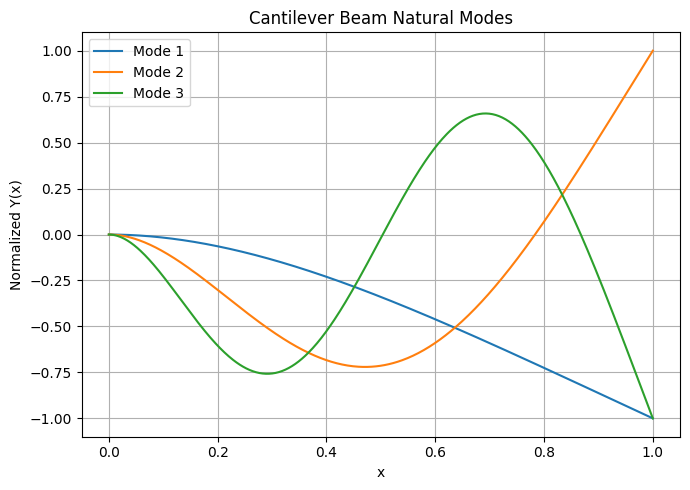

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar


# ======================================
# characteristic equation
# cosh(betaL)cos(betaL) + 1 = 0
# ======================================

def char_eq(betaL):
    return np.cosh(betaL)*np.cos(betaL) + 1


# ======================================
# find eigenvalues automatically
# (如果考试不让用scipy，就直接写死三个root)
# ======================================

def find_roots(n_modes=3):
    roots = []
    
    # root roughly near:
    # (2n-1)*pi/2
    guesses = [(1.5,2.5),(4,5.5),(7,9),(10,12)]
    
    for g in guesses[:n_modes]:
        sol = root_scalar(char_eq, bracket=g)
        roots.append(sol.root)
        
    return np.array(roots)


# ======================================
# mode shape
# ======================================

def mode_shape(beta, L, x):
    
    betaL = beta*L
    
    # coefficient ratio
    C = (np.sin(betaL) + np.sinh(betaL)) / (np.cos(betaL) + np.cosh(betaL))
    
    Y = (
        np.cos(beta*x)
        - np.cosh(beta*x)
        + C*(np.sin(beta*x) - np.sinh(beta*x))
    )
    
    # normalize
    return Y / np.max(np.abs(Y))


# ======================================
# main function
# EI, rhoA optional
# ======================================

def cantilever_modes(L=1, EI=None, rhoA=None, n_modes=3):
    
    roots = find_roots(n_modes)
    
    betas = roots / L
    
    x = np.linspace(0, L, 400)
    
    plt.figure(figsize=(8,5))
    
    for i, beta in enumerate(betas):
        Y = mode_shape(beta, L, x)
        plt.plot(x, Y, label=f"Mode {i+1}")
        
        # 如果给了参数 → 算自然频率
        if EI is not None and rhoA is not None:
            omega = beta**2 * np.sqrt(EI / rhoA)
            print(f"Mode {i+1}: ω = {omega:.3f} rad/s")
        else:
            print(f"Mode {i+1}: βL = {roots[i]:.3f}")
    
    plt.title("Cantilever Beam Mode Shapes")
    plt.xlabel("x")
    plt.ylabel("Normalized displacement")
    plt.legend()
    plt.grid()
    plt.show()


# ======================================
# 用法
# ======================================

# 情况1：没有物理参数（考试最常见）
cantilever_modes(L=1)


# 情况2：有数值
# cantilever_modes(
#     L=2,
#     EI=210e9*8.33e-6,   # example
#     rhoA=7800*0.003
# )
